<h3 style="text-align:center;color:green">Audio Loading and Signal Analysis</h3>

===== Signal Information =====
Sampling Rate      : 16000 Hz
Number of Samples  : 100533
Duration           : 6.2833125 seconds
Maximum Amplitude  : 1.0
Minimum Amplitude  : -0.7464952494850841


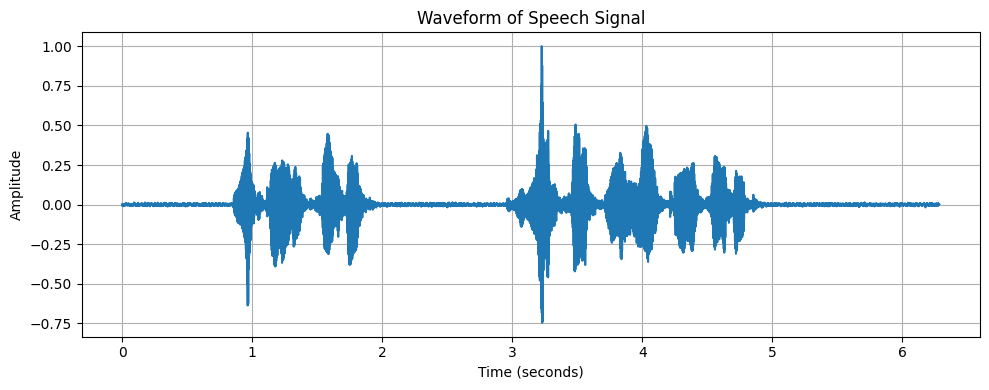

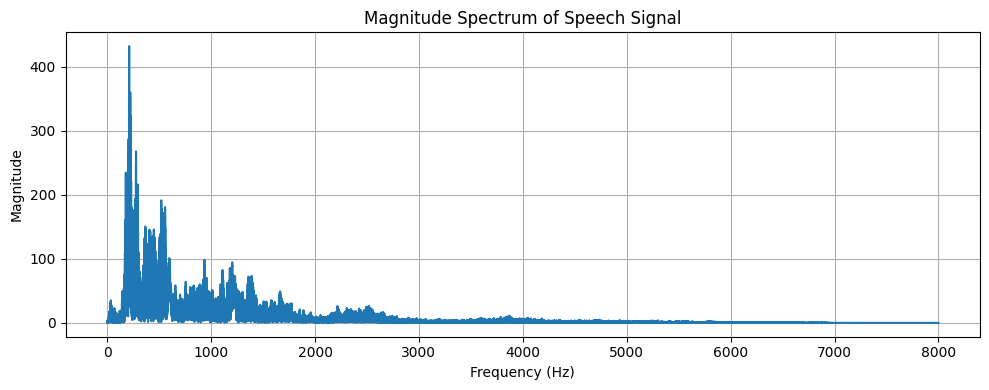

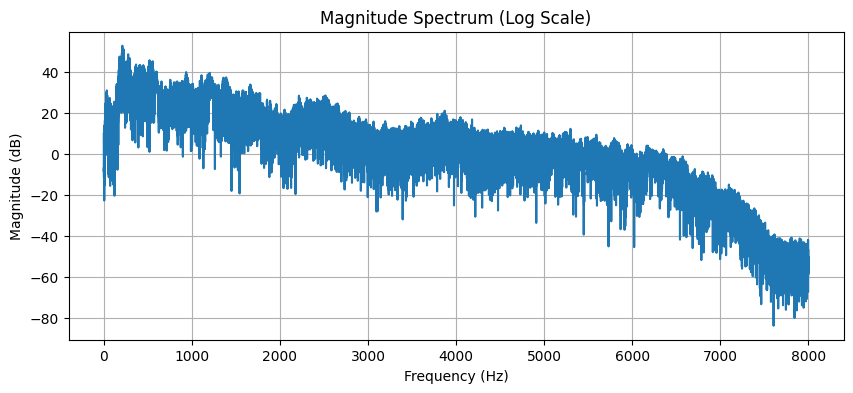

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import os

# =========================================================
# Q1. Audio Loading and Signal Analysis
# =========================================================

# -----------------------------
# 1. Load WAV File
# -----------------------------
file_path = "anger.wav"   # Change to your file path

if not os.path.exists(file_path):
    print("Error: File not found.")
    exit()

sampling_rate, signal = wavfile.read(file_path)

# Convert stereo → mono if needed
if len(signal.shape) == 2:
    signal = signal.mean(axis=1)

# Normalize signal (recommended for analysis)
signal = signal / np.max(np.abs(signal))


# -----------------------------
# 2. Basic Signal Information
# -----------------------------
num_samples = len(signal)
duration = num_samples / sampling_rate
max_amp = np.max(signal)
min_amp = np.min(signal)

print("===== Signal Information =====")
print("Sampling Rate      :", sampling_rate, "Hz")
print("Number of Samples  :", num_samples)
print("Duration           :", duration, "seconds")
print("Maximum Amplitude  :", max_amp)
print("Minimum Amplitude  :", min_amp)


# -----------------------------
# 3. Plot Waveform
# -----------------------------
time_axis = np.linspace(0, duration, num_samples, endpoint=False)

plt.figure(figsize=(10,4))
plt.plot(time_axis, signal)
plt.title("Waveform of Speech Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 4. FFT and Magnitude Spectrum
# -----------------------------
fft_values = np.fft.rfft(signal)
fft_magnitude = np.abs(fft_values)

freq_axis = np.fft.rfftfreq(num_samples, d=1/sampling_rate)


# -----------------------------
# 5. Plot Magnitude Spectrum
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(freq_axis, fft_magnitude)
plt.title("Magnitude Spectrum of Speech Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Plot Magnitude Spectrum dB
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(freq_axis, 20*np.log10(fft_magnitude + 1e-8))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Magnitude Spectrum (Log Scale)")
plt.grid()
plt.show()


<h3 style="text-align:center;color:yellow">Framing and Windowing</h3>

Total number of frames: 627


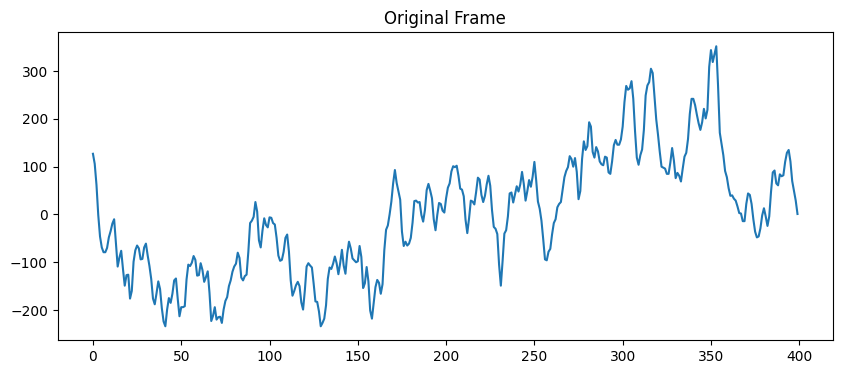

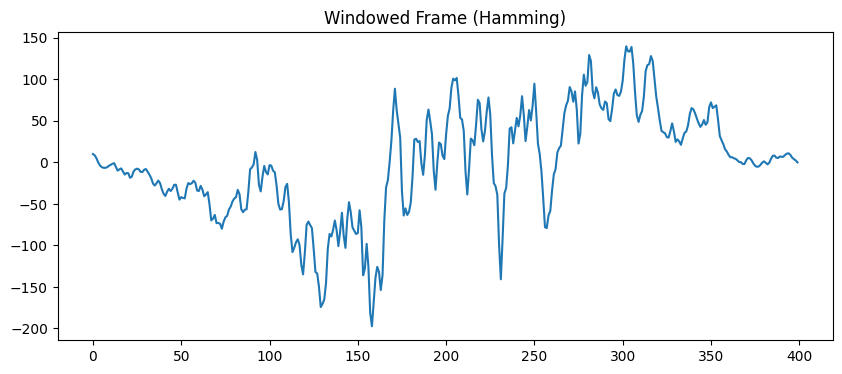

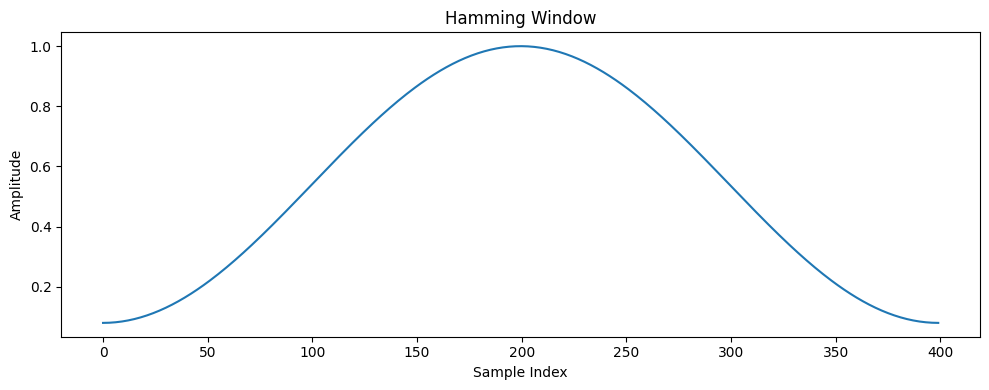

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# ----------------------------
# Load speech signal
# ----------------------------
fs, signal = wavfile.read("anger.wav")  # Replace with your file

# If stereo, convert to mono
if len(signal.shape) > 1:
    signal = signal.mean(axis=1)

signal = signal.astype(float)

# ----------------------------
# Framing parameters
# ----------------------------
frame_size_ms = 25      # 25 ms
frame_shift_ms = 10     # 10 ms

frame_length = int(fs * frame_size_ms / 1000)
frame_step = int(fs * frame_shift_ms / 1000)

signal_length = len(signal)

# ----------------------------
# Compute total number of frames
# ----------------------------
num_frames = int(np.ceil((signal_length - frame_length) / frame_step)) + 1

# Zero padding (if needed)
pad_length = num_frames * frame_step + frame_length
z = np.zeros(pad_length - signal_length)
padded_signal = np.append(signal, z)

# ----------------------------
# Create frames
# ----------------------------
frames = np.zeros((num_frames, frame_length))

for i in range(num_frames):
    start = i * frame_step
    end = start + frame_length
    frames[i] = padded_signal[start:end]

print("Total number of frames:", num_frames)

# ----------------------------
# Apply Hamming window
# ----------------------------
hamming_window = np.hamming(frame_length)
windowed_frames = frames * hamming_window

# ----------------------------
# Plot two sample frames
# ----------------------------
frame_index = 10  # You can change this


plt.figure(figsize=(10,4))
plt.plot(frames[frame_index])
plt.title("Original Frame")

plt.figure(figsize=(10,4))
plt.plot(windowed_frames[frame_index])
plt.title("Windowed Frame (Hamming)")

plt.figure(figsize=(10,4))
plt.plot(hamming_window)
plt.title("Hamming Window")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


<h3 style="text-align:center;color:aliceblue">STFT and Spectrogram Generation</h3>

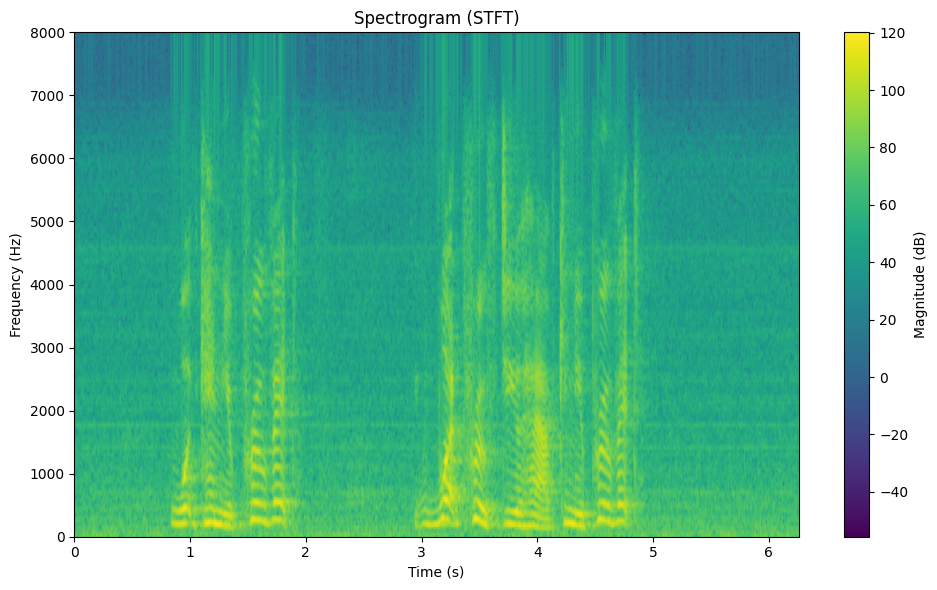

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# ----------------------------
# Load speech signal
# ----------------------------
fs, signal = wavfile.read("anger.wav")  # Replace with your file

# Convert to mono if stereo
if len(signal.shape) > 1:
    signal = signal.mean(axis=1)

signal = signal.astype(float)

# ----------------------------
# Framing parameters
# ----------------------------
frame_size_ms = 25
frame_shift_ms = 10

frame_length = int(fs * frame_size_ms / 1000)
frame_step = int(fs * frame_shift_ms / 1000)

signal_length = len(signal)

# Compute number of frames
num_frames = int(np.ceil((signal_length - frame_length) / frame_step)) + 1

# Zero padding
pad_length = num_frames * frame_step + frame_length
padded_signal = np.append(signal, np.zeros(pad_length - signal_length))

# Create frames
frames = np.zeros((num_frames, frame_length))
for i in range(num_frames):
    start = i * frame_step
    frames[i] = padded_signal[start:start + frame_length]

# ----------------------------
# Apply Hamming Window
# ----------------------------
window = np.hamming(frame_length)
windowed_frames = frames * window

# ----------------------------
# STFT using rFFT
# ----------------------------
fft_size = frame_length
stft = np.fft.rfft(windowed_frames, n=fft_size)

# Magnitude spectrum
magnitude = np.abs(stft)

# Convert to dB scale
eps = 1e-10  # avoid log(0)
magnitude_db = 20 * np.log10(magnitude + eps)

# ----------------------------
# Plot Spectrogram
# ----------------------------
plt.figure(figsize=(10,6))

time_axis = np.arange(num_frames) * frame_step / fs
freq_axis = np.fft.rfftfreq(fft_size, d=1/fs)

plt.pcolormesh(time_axis, freq_axis, magnitude_db.T, shading='gouraud')
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title("Spectrogram (STFT)")
plt.colorbar(label="Magnitude (dB)")
plt.tight_layout()
plt.show()

<h3 style="text-align:center;color:red">MFCC Extraction</h3>

MFCC shape: (627, 13)


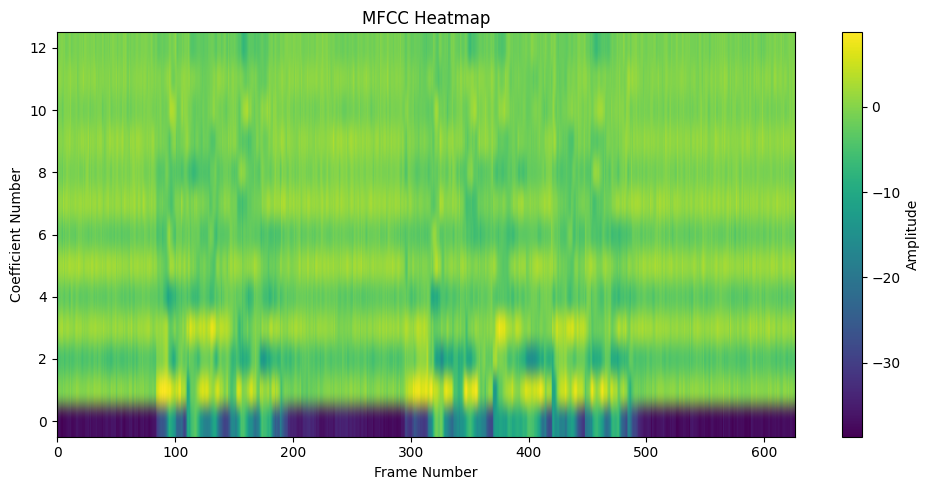

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fftpack import dct

# -----------------------------
# 1. Load audio and convert to mono
# -----------------------------
fs, signal = wavfile.read("anger.wav")
if signal.ndim > 1:
    signal = signal.mean(axis=1)
signal = signal.astype(float)

# Optional: normalize
signal = signal / np.max(np.abs(signal))

# -----------------------------
# 2. Pre-emphasis
# -----------------------------
pre_emphasis = 0.97
signal = np.append(signal[0], signal[1:] - pre_emphasis * signal[:-1])

# -----------------------------
# 3. Framing
# -----------------------------
frame_size, frame_shift = 0.025, 0.01  # seconds
N, H = int(frame_size*fs), int(frame_shift*fs)
num_frames = int(np.ceil((len(signal)-N)/H)) + 1

# Pad signal to fit frames
pad_len = num_frames*H + N
signal = np.append(signal, np.zeros(pad_len - len(signal)))

frames = np.array([signal[i*H:i*H+N] for i in range(num_frames)])
frames *= np.hamming(N)

# -----------------------------
# 4. FFT and Power Spectrum
# -----------------------------
fft_size = 512
spectrum = np.abs(np.fft.rfft(frames, fft_size))**2

# -----------------------------
# 5. Mel Filterbank
# -----------------------------
num_filters = 26

def hz_to_mel(h): return 2595*np.log10(1 + h/700)
def mel_to_hz(m): return 700*(10**(m/2595) - 1)

mel_points = np.linspace(hz_to_mel(0), hz_to_mel(fs/2), num_filters+2)
hz_points = mel_to_hz(mel_points)
bins = np.floor((fft_size+1)*hz_points/fs).astype(int)

filters = np.zeros((num_filters, fft_size//2+1))
for m in range(1, num_filters+1):
    left, center, right = bins[m-1], bins[m], bins[m+1]
    for k in range(left, center):
        filters[m-1, k] = (k-left)/(center-left)
    for k in range(center, right):
        filters[m-1, k] = (right-k)/(right-center)

mel_energy = np.dot(spectrum, filters.T)
mel_energy = np.where(mel_energy == 0, 1e-10, mel_energy)  # avoid log(0)
mel_energy = np.log(mel_energy)

# -----------------------------
# 6. DCT → MFCC
# -----------------------------
num_ceps = 13
mfcc = dct(mel_energy, type=2, axis=1, norm='ortho')[:,:num_ceps]

print("MFCC shape:", mfcc.shape)

# -----------------------------
# 7. Plot MFCC Heatmap
# -----------------------------
plt.figure(figsize=(10,5))
plt.imshow(mfcc.T, aspect='auto', origin='lower')
plt.title("MFCC Heatmap")
plt.xlabel("Frame Number")
plt.ylabel("Coefficient Number")
plt.colorbar(label="Amplitude")
plt.tight_layout()
plt.show()

 <h3 style="text-align:center;color:pink">Pitch Detection Using Autocorrelation</h3>

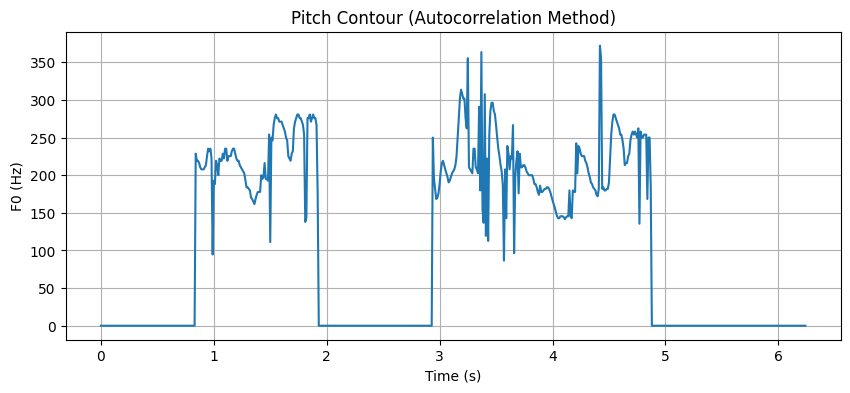

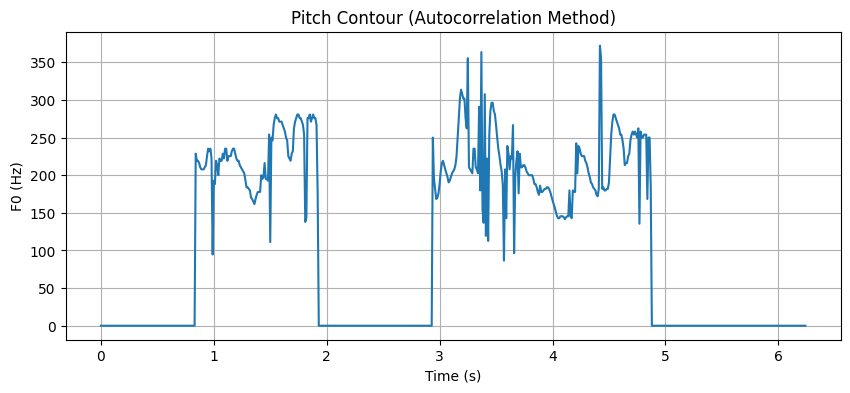

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import find_peaks

# -----------------------------
# 1. Load audio and convert to mono
# -----------------------------
fs, signal = wavfile.read("anger.wav")
if signal.ndim > 1:              # if stereo, average channels
    signal = signal.mean(axis=1)
signal = signal.astype(float)
signal = signal / np.max(np.abs(signal))  # normalize

# -----------------------------
# 2. Frame parameters
# -----------------------------
frame_size, frame_shift = 0.03, 0.01  # seconds
N, H = int(frame_size*fs), int(frame_shift*fs)
num_frames = int((len(signal)-N)/H)

# Pitch search range (Hz)
f_min, f_max = 50, 400
lag_min, lag_max = int(fs/f_max), int(fs/f_min)

energy_threshold = 0.01

# -----------------------------
# 3. Process each frame
# -----------------------------
pitch_contour, time_axis = [], []

for i in range(num_frames):
    start = i*H
    frame = signal[start:start+N] * np.hamming(N)  # Hamming window

    # Energy-based voiced/unvoiced detection
    if np.sum(frame**2) < energy_threshold:
        pitch_contour.append(0)
    else:
        # Autocorrelation
        autocorr = np.correlate(frame, frame, mode='full')[N-1:]
        r = autocorr[lag_min:lag_max]

        peaks, _ = find_peaks(r)
        if len(peaks) > 0:
            peak = peaks[np.argmax(r[peaks])]
            pitch_contour.append(fs/(peak+lag_min))
        else:
            pitch_contour.append(0)

    time_axis.append(start/fs)

# -----------------------------
# 4. Plot pitch contour
# -----------------------------
# pitch_voiced = [f0 for f0 in pitch_contour if f0 > 0]
# time_voiced = [t for t, f0 in zip(time_axis, pitch_contour) if f0 > 0]
                                                                              #-- for voiced only
# plt.figure(figsize=(10,4))
# plt.plot(time_voiced, pitch_voiced, marker='o', linestyle='-') 
       
plt.figure(figsize=(10,4))
plt.plot(time_axis, pitch_contour)
plt.xlabel("Time (s)")
plt.ylabel("F0 (Hz)")
plt.title("Pitch Contour (Autocorrelation Method)")
plt.grid(True)
plt.show()


<h3 style="text-align:center;color:green">Speech Enhancement by Spectral Subtraction </h3>

===== SNR RESULTS =====
SNR Before : 9.99 dB
SNR After  : 16.10 dB
Improvement: 6.11 dB


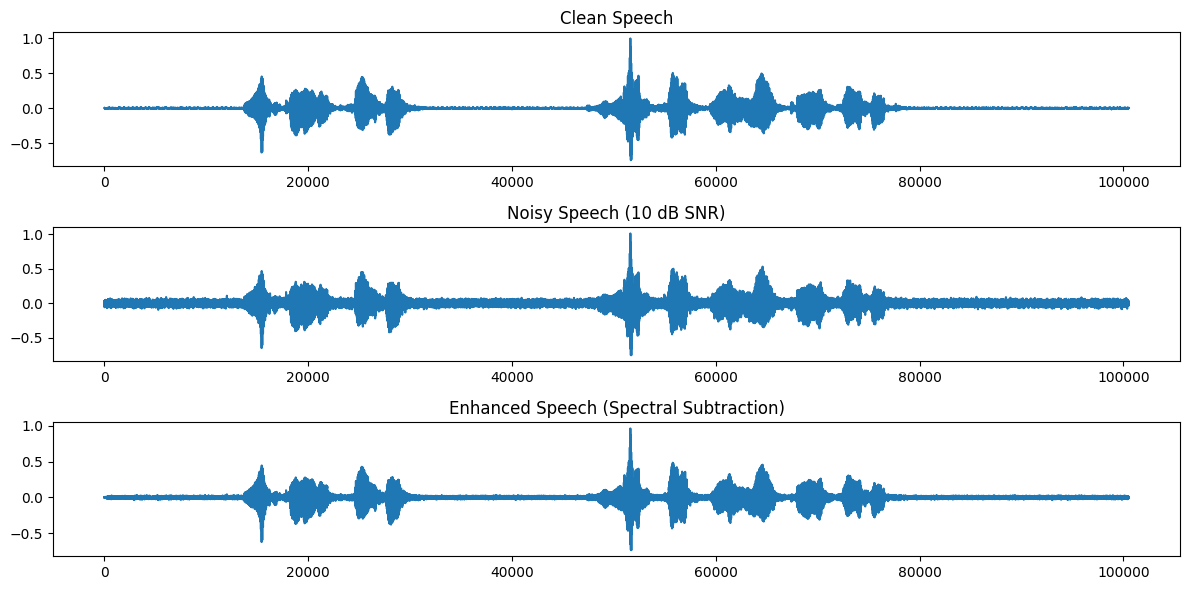

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft, istft
import soundfile as sf

# ============================================================
# 1. Load & Prepare Clean Speech
# ============================================================
fs, clean = wavfile.read("anger.wav")

clean = clean.astype(np.float32)
clean /= np.max(np.abs(clean))
if clean.ndim == 2:   # stereo → mono
    clean = clean.mean(axis=1)

# ============================================================
# 2. Add White Noise
# ============================================================
def add_noise(x, snr_db):
    p_signal = np.mean(x**2)
    p_noise = p_signal / (10**(snr_db/10))
    noise = np.random.normal(0, np.sqrt(p_noise), x.shape)
    return x + noise

snr_target = 10
noisy = add_noise(clean, snr_target)

# ============================================================
# 3. SNR Function
# ============================================================
snr = lambda ref, est: 10*np.log10(np.sum(ref**2)/np.sum((ref-est)**2))

snr_before = snr(clean, noisy)

# ============================================================
# 4. Spectral Subtraction
# ============================================================
def spectral_subtraction(x, fs, noise_frames=6):
    f, t, Z = stft(x, fs=fs, nperseg=1024)
    mag, phase = np.abs(Z), np.angle(Z)

    noise_est = np.mean(mag[:, :noise_frames], axis=1, keepdims=True)
    mag_clean = np.maximum(mag - noise_est, 1e-8)

    _, enhanced = istft(mag_clean * np.exp(1j*phase), fs=fs, nperseg=1024)
    return enhanced

enhanced = spectral_subtraction(noisy, fs)[:len(clean)]

# ============================================================
# 5. Final SNR
# ============================================================
snr_after = snr(clean, enhanced)

# ============================================================
# 6. Save Files
# ============================================================
sf.write("noisy_speech.wav", noisy, fs)
sf.write("enhanced_speech.wav", enhanced, fs)

# ============================================================
# 7. Results
# ============================================================
print("===== SNR RESULTS =====")
print(f"SNR Before : {snr_before:.2f} dB")
print(f"SNR After  : {snr_after:.2f} dB")
print(f"Improvement: {snr_after - snr_before:.2f} dB")

# Optional Plot
plt.figure(figsize=(12,6))
for i, (sig, title) in enumerate([
    (clean, "Clean Speech"),
    (noisy, "Noisy Speech (10 dB SNR)"),
    (enhanced, "Enhanced Speech (Spectral Subtraction)")
]):
    plt.subplot(3,1,i+1)
    plt.title(title)
    plt.plot(sig)

plt.tight_layout()
plt.show()

<h3 style="text-align:center;color:lightgreen">DTW-Based Isolated Word Recognition</h3>

In [2]:
import os
import numpy as np
from scipy.io import wavfile
from python_speech_features import mfcc
from dtw import dtw
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import soundfile as sf

# ===============================
# 1. Dataset Preparation
# ===============================
# Folder structure:
# ./data/<word>/<sample>.wav
dataset_path = "./data"
words = ['anger', 'hap', 'neutral', 'sad']  # your word labels

train_files = []
train_labels = []
test_files = []
test_labels = []

for word in words:
    word_path = os.path.join(dataset_path, word)
    if not os.path.exists(word_path):
        continue
    files = sorted([f for f in os.listdir(word_path) if f.endswith('.wav')])
    # At least 3 training, 2 testing samples
    if len(files) < 5:
        raise ValueError(f"Not enough samples for word '{word}'")
    for f in files[:3]:
        train_files.append(os.path.join(word_path, f))
        train_labels.append(word)
    for f in files[3:]:
        test_files.append(os.path.join(word_path, f))
        test_labels.append(word)

print(f"Training samples: {len(train_files)}, Testing samples: {len(test_files)}")

# ===============================
# 2. MFCC Extraction
# ===============================
def extract_mfcc(file_path):
    fs, signal = wavfile.read(file_path)
    # convert to float32
    if signal.dtype != np.float32:
        signal = signal.astype(np.float32) / np.max(np.abs(signal))
    # stereo -> mono
    if len(signal.shape) == 2:
        signal = np.mean(signal, axis=1)
    # Check non-empty
    if len(signal) == 0:
        return None
    # Extract MFCCs
    mfcc_feat = mfcc(signal, samplerate=fs, numcep=13, nfft=1024)
    if mfcc_feat.size == 0:
        return None
    return mfcc_feat

train_mfccs = [extract_mfcc(f) for f in train_files]
test_mfccs = [extract_mfcc(f) for f in test_files]

# Remove None (empty) samples
train_mfccs, train_labels = zip(*[(m, l) for m, l in zip(train_mfccs, train_labels) if m is not None])
test_mfccs, test_labels = zip(*[(m, l) for m, l in zip(test_mfccs, test_labels) if m is not None])

# ===============================
# 3. DTW Classification (Fixed for dtw-python >=1.0)
# ===============================
pred_labels = []
for test_feat in test_mfccs:
    min_dist = float('inf')
    pred_word = None
    for train_feat, label in zip(train_mfccs, train_labels):
        # dtw now returns a DTW object
        d = dtw(test_feat, train_feat, dist_method=lambda x, y: np.linalg.norm(x - y))
        if d.distance < min_dist:
            min_dist = d.distance
            pred_word = label
    pred_labels.append(pred_word)


# ===============================
# 4. Compute Accuracy
# ===============================
accuracy = np.sum(np.array(pred_labels) == np.array(test_labels)) / len(test_labels)
print(f"Recognition Accuracy: {accuracy*100:.2f}%")

# ===============================
# 5. Confusion Matrix
# ===============================
cm = confusion_matrix(test_labels, pred_labels, labels=words)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=words)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - DTW Isolated Word Recognition")
plt.show()


ModuleNotFoundError: No module named 'python_speech_features'

<h3 style="text-align:center;color:lightblue">Voice Activity Detection (VAD) and Segmentation</h3>

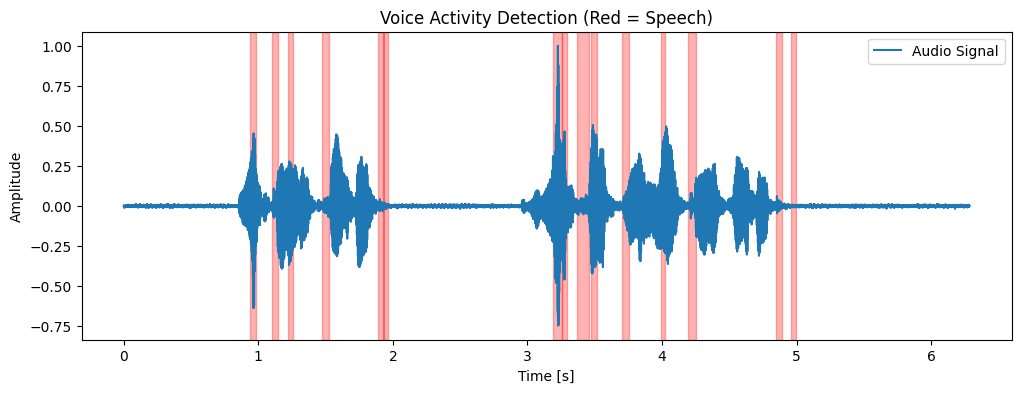

Saved 15 speech segments in 'speech_segments/'


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import os
import soundfile as sf

# ===============================
# 1. Load Audio
# ===============================
fs, signal = wavfile.read("anger.wav")  # Replace with your audio file

# Convert to float
if signal.dtype != np.float32:
    signal = signal.astype(np.float32) / np.max(np.abs(signal))

# Convert to mono if stereo
if len(signal.shape) == 2:
    signal = np.mean(signal, axis=1)

# ===============================
# 2. Frame Parameters
# ===============================
frame_size = 0.025  # 25 ms
frame_shift = 0.01  # 10 ms
N = int(frame_size * fs)
step = int(frame_shift * fs)

def enframe(signal, N, step):
    """Split signal into overlapping frames"""
    frames = []
    for start in range(0, len(signal) - N + 1, step):
        frames.append(signal[start:start+N])
    return np.array(frames)

frames = enframe(signal, N, step)

# ===============================
# 3. Compute STE and ZCR
# ===============================
def short_time_energy(frame):
    return np.sum(frame ** 2) / len(frame)

def zero_crossing_rate(frame):
    return np.sum(np.abs(np.diff(np.sign(frame)))) / (2 * len(frame))

STE = np.array([short_time_energy(f) for f in frames])
ZCR = np.array([zero_crossing_rate(f) for f in frames])

# ===============================
# 4. Rule-Based Speech Detection
# ===============================
# Thresholds (tune if needed)
STE_thresh = 0.3 * np.max(STE)
ZCR_thresh = 0.3 * np.max(ZCR)

speech_frames = np.where((STE > STE_thresh) | (ZCR > ZCR_thresh))[0]

# Group consecutive speech frames into regions
speech_regions = []
if len(speech_frames) > 0:
    start = speech_frames[0]
    for i in range(1, len(speech_frames)):
        if speech_frames[i] > speech_frames[i-1] + 1:
            end = speech_frames[i-1]
            speech_regions.append((start, end))
            start = speech_frames[i]
    # Add last region
    speech_regions.append((start, speech_frames[-1]))

# Convert frame indices to sample indices
speech_regions_samples = [(s*step, e*step+N) for (s,e) in speech_regions]

# ===============================
# 5. Plot Detected Speech Regions
# ===============================
time = np.arange(len(signal)) / fs

plt.figure(figsize=(12,4))
plt.plot(time, signal, label="Audio Signal")
for (s,e) in speech_regions_samples:
    plt.axvspan(s/fs, e/fs, color='red', alpha=0.3)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Voice Activity Detection (Red = Speech)")
plt.legend()
plt.show()

# ===============================
# 6. Save Speech Segments
# ===============================
os.makedirs("speech_segments", exist_ok=True)

for i, (s, e) in enumerate(speech_regions_samples):
    segment = signal[s:e]
    sf.write(f"speech_segments/segment_{i+1}.wav", segment, fs)

print(f"Saved {len(speech_regions_samples)} speech segments in 'speech_segments/'")


<h3 style="text-align:center;color:lightdark">Speaker Identification using Simple Embedding</h3>

In [ ]:
import os
import numpy as np
from scipy.io import wavfile
from python_speech_features import mfcc, delta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ===============================
# 1. Dataset Preparation
# ===============================
# Folder structure:
# ./data/<speaker>/<sample>.wav
dataset_path = "./data"
speakers = ['spk1','spk2','spk3']  # Add your speaker folders

files = []
labels = []

for spk in speakers:
    spk_path = os.path.join(dataset_path, spk)
    if not os.path.exists(spk_path):
        continue
    spk_files = sorted([f for f in os.listdir(spk_path) if f.endswith('.wav')])
    for f in spk_files:
        files.append(os.path.join(spk_path, f))
        labels.append(spk)

print(f"Total samples: {len(files)}")

# ===============================
# 2. Feature Extraction (Simple Embedding)
# ===============================
def extract_embedding(file_path):
    fs, signal = wavfile.read(file_path)
    if signal.dtype != np.float32:
        signal = signal.astype(np.float32) / np.max(np.abs(signal))
    if len(signal.shape) == 2:
        signal = np.mean(signal, axis=1)
    # MFCC
    mfcc_feat = mfcc(signal, samplerate=fs, numcep=13, nfft=1024)
    # Delta MFCC
    delta_feat = delta(mfcc_feat, 2)
    # Embedding: mean MFCC + mean delta
    embedding = np.hstack((np.mean(mfcc_feat, axis=0), np.mean(delta_feat, axis=0)))
    return embedding

embeddings = np.array([extract_embedding(f) for f in files])
labels = np.array(labels)

# ===============================
# 3. Train/Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.3, stratify=labels, random_state=42
)

# ===============================
# 4. Feature Scaling
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 5. Train Classifier (KNN)
# ===============================
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

# ===============================
# 6. Evaluate
# ===============================
y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Speaker ID Accuracy: {accuracy*100:.2f}%\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# ===============================
# 7. Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred, labels=speakers)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=speakers)
disp.plot(cmap=plt.cm.Blues)
plt.title("Speaker Identification Confusion Matrix")
plt.show()


<h3 style="text-align:center;color:red">Real-Time Command Recognition</h3>

In [ ]:
import sounddevice as sd
import numpy as np
from scipy.io.wavfile import write
from python_speech_features import mfcc
from dtw import dtw

# ===============================
# 1. Setup Templates for Commands
# ===============================
# Assume we have pre-recorded templates for each command
# e.g., 1 example per command
command_templates = {
    "start": "templates/start.wav",
    "stop": "templates/stop.wav"
}

# Extract MFCC for templates
def load_template_mfcc(file_path):
    from scipy.io import wavfile
    fs, signal = wavfile.read(file_path)
    if signal.dtype != np.float32:
        signal = signal.astype(np.float32) / np.max(np.abs(signal))
    if len(signal.shape) == 2:
        signal = np.mean(signal, axis=1)
    return mfcc(signal, samplerate=fs, numcep=13, nfft=1024)

template_mfccs = {cmd: load_template_mfcc(path) for cmd, path in command_templates.items()}

# ===============================
# 2. Record Audio from Microphone
# ===============================
duration = 2  # seconds
fs = 16000  # sampling rate

print("Recording audio... Speak now!")
recorded_signal = sd.rec(int(duration * fs), samplerate=fs, channels=1)
sd.wait()
recorded_signal = recorded_signal.flatten()

# Optional: save recording
write("recorded_command.wav", fs, (recorded_signal * 32767).astype(np.int16))

# ===============================
# 3. Extract MFCC of Recorded Audio
# ===============================
recorded_mfcc = mfcc(recorded_signal, samplerate=fs, numcep=13, nfft=1024)

# ===============================
# 4. Classify Using DTW Nearest Template
# ===============================
min_dist = float('inf')
predicted_command = None

for cmd, tmpl_mfcc in template_mfccs.items():
    dist = dtw(recorded_mfcc, tmpl_mfcc, dist=lambda x, y: np.linalg.norm(x - y)).distance
    if dist < min_dist:
        min_dist = dist
        predicted_command = cmd

# ===============================
# 5. Show Predicted Command
# ===============================
print(f"Predicted Command: {predicted_command}")

# ===============================
# 6. Limitation
# ===============================
print("\nLimitation: Recognition accuracy is low for noisy environments or if user pronunciation differs from template. Only one template per command is used.")
